# AllSides Same-Event Sequence Pattern Analysis

This notebook analyses sequential patterns of predicted argumentative-unit types in the final filtered AllSides same-event predictions. Sequence patterns are based on assumption, testimony, anecdote, and statistics, while the residual `other` category is excluded. Consecutive occurrences of the same argumentative-unit type are collapsed into a single sequence element.

## 1. Load Final Predictions

In [1]:
from pathlib import Path
import pandas as pd

PREDICTIONS_PATH = Path(
    "../results/model_predictions/allsides_same_events_model_predictions_final.csv"
)

df = pd.read_csv(PREDICTIONS_PATH)

df.shape

(32114, 22)

## 2. Construct Sequences

In [2]:
LABEL_MAP = {
    "assumption": "AS",
    "testimony": "TE",
    "anecdote": "AN",
    "statistics": "ST",
}

sequence_spans = (
    df.loc[
        df["label"].isin(LABEL_MAP),
        ["event_id", "orientation", "span_id", "span_start", "span_end", "label"],
    ]
    .assign(sequence_label=lambda x: x["label"].map(LABEL_MAP))
    .sort_values(["event_id", "orientation", "span_start", "span_end", "span_id"])
    .reset_index(drop=True)
)

sequence_spans.head()

,event_id,orientation,span_id,span_start,span_end,label,sequence_label
0,1,Center,0,0,83,assumption,AS
1,1,Center,1,86,151,assumption,AS
2,1,Center,2,151,182,testimony,TE
3,1,Center,3,184,448,testimony,TE
4,1,Center,4,449,639,testimony,TE


### 2.1 Consecutive Labels into Change Flows

In [3]:
def collapse_consecutive(labels):
    collapsed = []

    for label in labels:
        if not collapsed or label != collapsed[-1]:
            collapsed.append(label)

    return collapsed


article_sequences = (
    sequence_spans
    .groupby(["event_id", "orientation"])["sequence_label"]
    .agg(list)
    .reset_index(name="raw_sequence")
)

article_sequences["change_flow"] = (
    article_sequences["raw_sequence"]
    .apply(collapse_consecutive)
)

article_sequences.head()

,event_id,orientation,raw_sequence,change_flow
0,1,Center,"[AS, AS, TE, TE, TE, TE, TE, TE, TE, AS, AN, A...","[AS, TE, AS, AN, TE, AS]"
1,1,Left,"[AS, AS, AS, AS, TE, AN, AS, TE, TE, AN, TE, S...","[AS, TE, AN, AS, TE, AN, TE, ST, AS, AN, TE, A..."
2,1,Right,"[AS, TE, AS, AS, TE, AS, AN, AS, AS, TE, AS, T...","[AS, TE, AS, TE, AS, AN, AS, TE, AS, TE, AS, A..."
3,2,Center,"[AN, AS, TE, TE, TE, TE, AS, AS, AN, AS, AN, A...","[AN, AS, TE, AS, AN, AS, AN, AS, TE, AN, AS, A..."
4,2,Left,"[AN, AN, TE, TE, TE, TE, TE, TE, TE, TE, AS, A...","[AN, TE, AS, TE, AN, AS, TE, AS, TE, AN, TE, A..."


### 2.2 Validate Sequence Coverage

In [4]:
(
    len(article_sequences),
    article_sequences["event_id"].nunique(),
    article_sequences.groupby("event_id")["orientation"].nunique().value_counts()
)

(660,
 220,
 orientation
 3    220
 Name: count, dtype: int64)

### 2.3 Sequence Lengths

In [5]:
article_sequences["raw_length"] = (
    article_sequences["raw_sequence"].str.len()
)

article_sequences["flow_length"] = (
    article_sequences["change_flow"].str.len()
)

article_sequences[
    ["raw_length", "flow_length"]
].describe().round(2)

,raw_length,flow_length
count,660.00,660.00
mean,47.88,22.47
std,32.38,14.05
min,3.00,1.00
25%,28.00,13.00
50%,41.00,19.00
75%,60.00,29.00
max,373.00,98.00


## 3. Overall Change-Flow Patterns

In [6]:
article_sequences["flow"] = (
    article_sequences["change_flow"].apply(tuple)
)

flow_counts = (
    article_sequences["flow"]
    .value_counts()
    .rename("articles")
    .to_frame()
)

flow_counts["percentage"] = (
    flow_counts["articles"]
    / len(article_sequences)
    * 100
)

flow_counts.head(15).round(2)

,articles,percentage
flow,,
"(AS,)",5,0.76
"(AN,)",4,0.61
"(AS, AN)",3,0.45
"(AN, TE)",2,0.30
"(AN, TE, AN, TE, AS, TE, AN, TE, AN, TE, AN)",2,0.30
"(AS, TE, AS, AN, AS, TE)",2,0.30
"(AN, TE, AN, TE, AN, TE, AN, TE, AN, TE, AN)",2,0.30
"(AN, TE, AN, TE, AS, AN)",2,0.30
"(AS, TE)",2,0.30


In [7]:
unique_flows = flow_counts.shape[0]
singleton_flows = (flow_counts["articles"] == 1).sum()
top15_coverage = flow_counts.head(15)["articles"].sum() / len(article_sequences) * 100

unique_flows, singleton_flows, round(top15_coverage, 2)

(645, np.int64(636), np.float64(4.55))

## 4. Overall Transition Patterns

In [8]:
transition_records = []

for row in article_sequences.itertuples(index=False):
    for first, second in zip(row.change_flow, row.change_flow[1:]):
        transition_records.append({
            "event_id": row.event_id,
            "orientation": row.orientation,
            "from_label": first,
            "to_label": second,
        })

transitions_df = pd.DataFrame(transition_records)

transitions_df.head()

,event_id,orientation,from_label,to_label
0,1,Center,AS,TE
1,1,Center,TE,AS
2,1,Center,AS,AN
3,1,Center,AN,TE
4,1,Center,TE,AS


In [9]:
# overall transition frequencies and %
transition_frequency = (
    transitions_df
    .groupby(["from_label", "to_label"])
    .size()
    .rename("count")
    .reset_index()
)

transition_frequency["percentage"] = (
    transition_frequency["count"]
    / transition_frequency["count"].sum()
    * 100
)

transition_frequency.sort_values(
    "count",
    ascending=False
).round(2)

,from_label,to_label,count,percentage
3,AS,AN,2343,16.53
0,AN,AS,2211,15.60
2,AN,TE,2034,14.35
10,TE,AS,1930,13.62
9,TE,AN,1868,13.18
5,AS,TE,1865,13.16
4,AS,ST,504,3.56
7,ST,AS,470,3.32
8,ST,TE,270,1.91
11,TE,ST,235,1.66


In [10]:
label_order = ["AS", "TE", "AN", "ST"]

transition_matrix = (
    transitions_df
    .groupby(["from_label", "to_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(
        index=label_order,
        columns=label_order,
        fill_value=0,
    )
)

transition_percentage_matrix = (
    transition_matrix
    .div(transition_matrix.sum(axis=1), axis=0)
    * 100
)

transition_percentage_matrix.round(2)

to_label,AS,TE,AN,ST
from_label,,,,
AS,0.00,39.58,49.72,10.70
TE,47.86,0.00,46.32,5.83
AN,49.49,45.52,0.00,4.99
ST,49.06,28.18,22.76,0.00


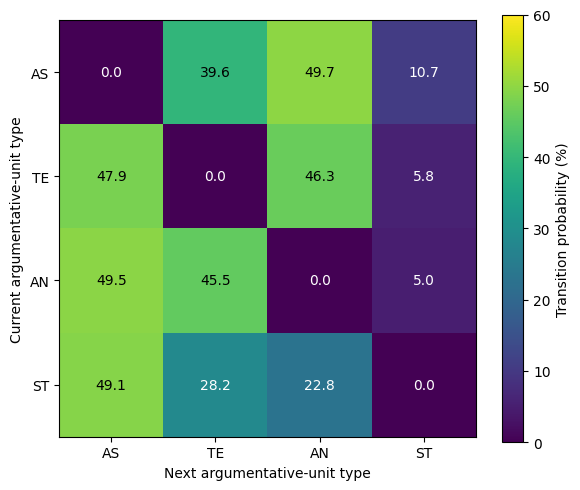

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(
    transition_percentage_matrix.values,
    cmap="viridis",
    vmin=0,
    vmax=60,
)

ax.set_xticks(range(len(label_order)))
ax.set_xticklabels(label_order)
ax.set_yticks(range(len(label_order)))
ax.set_yticklabels(label_order)

ax.set_xlabel("Next argumentative-unit type")
ax.set_ylabel("Current argumentative-unit type")

for i in range(len(label_order)):
    for j in range(len(label_order)):
        value = transition_percentage_matrix.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="black" if value > 30 else "white",
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Transition probability (%)")

plt.tight_layout()

plt.savefig(
    "../figures/allsides_same_events_overall_transition_matrix.pdf",
    bbox_inches="tight",
)

plt.show()

The overall transition matrix shows that most argumentative-unit changes occur among assumption, testimony, and anecdote. Assumption is followed most often by anecdote, while testimony and anecdote both transition frequently to assumption. Statistics is comparatively uncommon as a subsequent argumentative-unit type, although when statistics does occur it is most often followed by assumption. Overall, the same-event corpus therefore shows a transition structure dominated by movement among the three most frequent argumentative-unit categories.

## 5. Transition Patterns by Political Orientation

In [12]:
def make_transition_percentage_matrix(data):
    matrix = (
        data
        .groupby(["from_label", "to_label"])
        .size()
        .unstack(fill_value=0)
        .reindex(
            index=label_order,
            columns=label_order,
            fill_value=0,
        )
    )

    return matrix.div(matrix.sum(axis=1), axis=0) * 100


orientation_transition_matrices = {
    orientation: make_transition_percentage_matrix(
        transitions_df[
            transitions_df["orientation"] == orientation
        ]
    )
    for orientation in ["Center", "Left", "Right"]
}

orientation_transition_matrices["Center"].round(2)

to_label,AS,TE,AN,ST
from_label,,,,
AS,0.00,37.86,51.78,10.37
TE,48.12,0.00,45.45,6.42
AN,51.51,43.26,0.00,5.23
ST,47.37,29.82,22.81,0.00


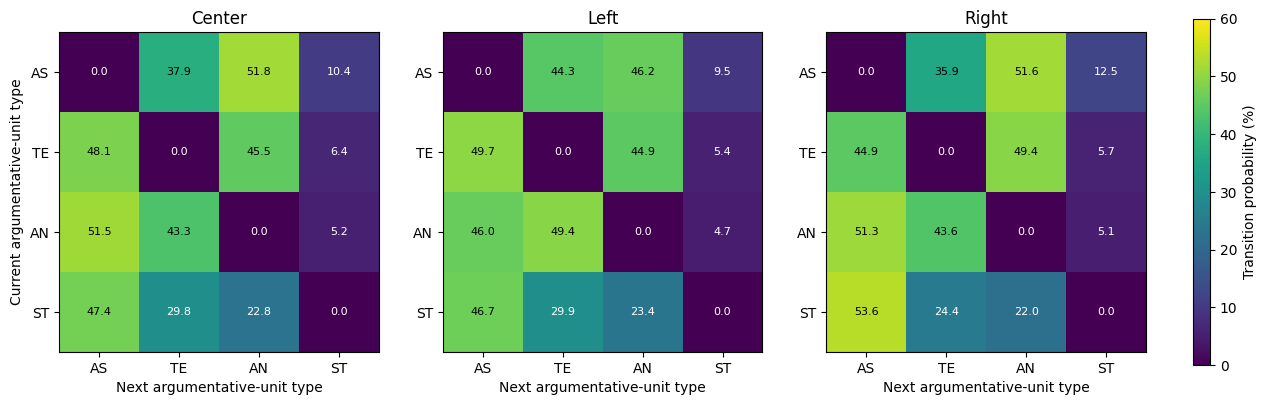

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, orientation in zip(
    axes,
    ["Center", "Left", "Right"],
):
    matrix = orientation_transition_matrices[orientation]

    image = ax.imshow(
        matrix.values,
        cmap="viridis",
        vmin=0,
        vmax=60,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(label_order)
    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(label_order)

    ax.set_title(orientation)
    ax.set_xlabel("Next argumentative-unit type")

axes[0].set_ylabel("Current argumentative-unit type")

for ax, orientation in zip(
    axes,
    ["Center", "Left", "Right"],
):
    matrix = orientation_transition_matrices[orientation]

    for i in range(len(label_order)):
        for j in range(len(label_order)):
            value = matrix.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                color="black" if value > 30 else "white",
                fontsize=8,
            )

colorbar = fig.colorbar(
    image,
    ax=axes,
    fraction=0.025,
    pad=0.04,
)
colorbar.set_label("Transition probability (%)")

plt.savefig(
    "../figures/allsides_same_events_transition_matrices_by_orientation.pdf",
    bbox_inches="tight",
)

plt.show()

The orientation transition matrices show broadly similar sequence structures across Center, Left, and Right articles. In all three orientations, most transitions occur among assumption, testimony, and anecdote, while transitions involving statistics remain comparatively infrequent. Some differences are nevertheless visible. Left articles show somewhat higher probabilities of assumption being followed by testimony and anecdote being followed by testimony, whereas Right articles show somewhat higher probabilities of assumption transitioning to statistics and statistics transitioning to assumption. Overall, the differences are modest and suggest variation in the relative balance of transitions rather than fundamentally different sequence structures across political orientations.

### 5.1 Starting and Ending Argumentative-Unit Types

In [14]:
article_sequences["start_label"] = (
    article_sequences["change_flow"].str[0]
)

article_sequences["end_label"] = (
    article_sequences["change_flow"].str[-1]
)

start_by_orientation = (
    pd.crosstab(
        article_sequences["orientation"],
        article_sequences["start_label"],
        normalize="index",
    )
    * 100
)

end_by_orientation = (
    pd.crosstab(
        article_sequences["orientation"],
        article_sequences["end_label"],
        normalize="index",
    )
    * 100
)

start_by_orientation.round(2), end_by_orientation.round(2)

(start_label     AN     AS    ST     TE
 orientation                           
 Center       34.55  50.91  3.64  10.91
 Left         44.55  40.00  3.18  12.27
 Right        41.36  41.82  5.00  11.82,
 end_label       AN     AS    ST     TE
 orientation                           
 Center       31.82  32.27  5.91  30.00
 Left         29.09  28.18  1.82  40.91
 Right        41.82  26.36  5.91  25.91)

Starting and ending argumentative-unit distributions show somewhat more visible orientation differences than the internal transition matrices. Center articles begin most frequently with assumption, whereas Left and Right articles show a higher proportion of anecdotal openings. Endings differ more clearly: Left articles end most often with testimony, while Right articles end most often with anecdote. Statistics remains uncommon at both sequence boundaries across all three orientations. These patterns suggest modest differences in how argumentative sequences are framed at their beginnings and endings, despite broadly similar internal transition structures.

## 6. Transition Patterns by Topic

In [15]:
article_metadata = (
    df
    .drop_duplicates(["event_id", "orientation"])
    .set_index(["event_id", "orientation"])[["topic"]]
)

article_sequences = (
    article_sequences
    .set_index(["event_id", "orientation"])
    .join(article_metadata)
    .reset_index()
)

article_sequences.head()

,event_id,orientation,raw_sequence,change_flow,raw_length,flow_length,flow,start_label,end_label,topic
0,1,Center,"[AS, AS, TE, TE, TE, TE, TE, TE, TE, AS, AN, A...","[AS, TE, AS, AN, TE, AS]",15,6,"(AS, TE, AS, AN, TE, AS)",AS,AS,Defense and Security
1,1,Left,"[AS, AS, AS, AS, TE, AN, AS, TE, TE, AN, TE, S...","[AS, TE, AN, AS, TE, AN, TE, ST, AS, AN, TE, A...",25,15,"(AS, TE, AN, AS, TE, AN, TE, ST, AS, AN, TE, A...",AS,AS,Defense and Security
2,1,Right,"[AS, TE, AS, AS, TE, AS, AN, AS, AS, TE, AS, T...","[AS, TE, AS, TE, AS, AN, AS, TE, AS, TE, AS, A...",71,45,"(AS, TE, AS, TE, AS, AN, AS, TE, AS, TE, AS, A...",AS,TE,Defense and Security
3,2,Center,"[AN, AS, TE, TE, TE, TE, AS, AS, AN, AS, AN, A...","[AN, AS, TE, AS, AN, AS, AN, AS, TE, AN, AS, A...",30,14,"(AN, AS, TE, AS, AN, AS, AN, AS, TE, AN, AS, A...",AN,AN,Criminal Justice
4,2,Left,"[AN, AN, TE, TE, TE, TE, TE, TE, TE, TE, AS, A...","[AN, TE, AS, TE, AN, AS, TE, AS, TE, AN, TE, A...",33,15,"(AN, TE, AS, TE, AN, AS, TE, AS, TE, AN, TE, A...",AN,AN,Criminal Justice


In [16]:
topic_event_counts = (
    article_sequences[
        ["event_id", "topic"]
    ]
    .drop_duplicates()
    ["topic"]
    .value_counts()
)

retained_topics = topic_event_counts[
    topic_event_counts >= 5
].index

len(retained_topics)

17

In [17]:
topic_transitions = transitions_df.merge(
    article_sequences[
        ["event_id", "orientation", "topic"]
    ],
    on=["event_id", "orientation"],
    how="left",
)

topic_transitions = topic_transitions[
    topic_transitions["topic"].isin(retained_topics)
]

topic_transitions.head()

,event_id,orientation,from_label,to_label,topic
0,1,Center,AS,TE,Defense and Security
1,1,Center,TE,AS,Defense and Security
2,1,Center,AS,AN,Defense and Security
3,1,Center,AN,TE,Defense and Security
4,1,Center,TE,AS,Defense and Security


In [18]:
topic_transition_matrices = {
    topic: make_transition_percentage_matrix(
        topic_transitions[
            topic_transitions["topic"] == topic
        ]
    )
    for topic in retained_topics
}

len(topic_transition_matrices)

17

In [19]:
topic_transition_summary = pd.DataFrame(
    {
        topic: {
            f"{from_label} → {to_label}":
                matrix.loc[from_label, to_label]
            for from_label in label_order
            for to_label in label_order
            if from_label != to_label
        }
        for topic, matrix in topic_transition_matrices.items()
    }
).T

topic_transition_summary = topic_transition_summary.loc[
    retained_topics
]

topic_transition_summary.round(2)

,AS → TE,AS → AN,AS → ST,TE → AS,TE → AN,TE → ST,AN → AS,AN → TE,AN → ST,ST → AS,ST → TE,ST → AN
topic,,,,,,,,,,,,
World,38.42,57.72,3.86,48.77,47.74,3.50,53.40,41.96,4.64,36.23,24.64,39.13
Economy and Jobs,31.48,25.91,42.61,55.56,18.28,26.16,49.78,28.38,21.83,57.46,26.35,16.19
Politics,41.41,50.84,7.74,59.41,38.61,1.98,60.83,35.42,3.75,65.71,11.43,22.86
Donald Trump,46.15,47.18,6.67,47.92,50.00,2.08,43.68,52.63,3.68,52.00,32.00,16.00
Middle East,49.29,47.39,3.32,44.24,50.56,5.20,34.69,62.04,3.27,21.43,57.14,21.43
Defense and Security,50.63,44.94,4.43,35.27,62.80,1.93,35.98,63.55,0.47,58.33,8.33,33.33
Immigration,50.79,35.71,13.49,44.29,47.86,7.86,37.10,58.87,4.03,42.42,33.33,24.24
Violence in America,48.72,51.28,0.00,24.14,74.14,1.72,18.99,78.21,2.79,0.00,25.00,75.00
2022 Elections,28.78,59.02,12.20,65.62,31.25,3.12,67.52,24.84,7.64,66.67,12.82,20.51


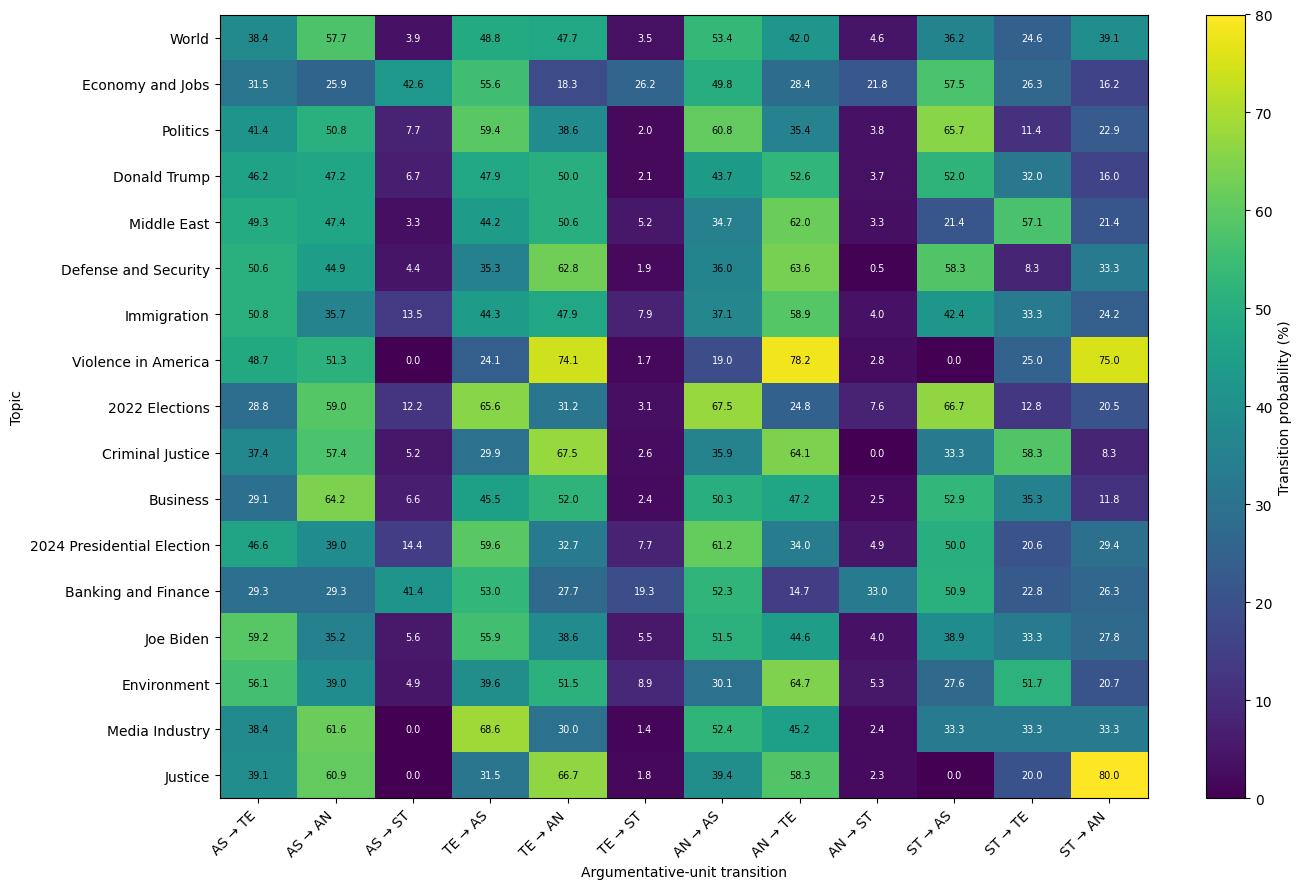

In [20]:
fig, ax = plt.subplots(figsize=(14, 9))

image = ax.imshow(
    topic_transition_summary.values,
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=80,
)

ax.set_xticks(range(len(topic_transition_summary.columns)))
ax.set_xticklabels(
    topic_transition_summary.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(range(len(topic_transition_summary.index)))
ax.set_yticklabels(topic_transition_summary.index)

ax.set_xlabel("Argumentative-unit transition")
ax.set_ylabel("Topic")

for i in range(len(topic_transition_summary.index)):
    for j in range(len(topic_transition_summary.columns)):
        value = topic_transition_summary.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.1f}",
            ha="center",
            va="center",
            color="black" if value > 35 else "white",
            fontsize=7,
        )

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Transition probability (%)")

plt.tight_layout()

plt.savefig(
    "../figures/allsides_same_events_topic_transition_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

Transition patterns vary across topics, although the dominant structure remains movement among assumption, testimony, and anecdote. Several topics show distinctive emphases. Economy and Jobs and Banking and Finance have comparatively higher probabilities of transitions involving statistics, while topics such as Violence in America, Criminal Justice, and Justice show stronger movement between testimony and anecdote. Some large percentages involving statistics occur in topics where statistics transitions are relatively infrequent and should therefore be carefully interpreted. Overall, topic appears to shape the relative balance of argumentative-unit transitions more visibly than political orientation, while the underlying transition network remains broadly similar across topics.

## 7. Transition Patterns by Outlet

In [21]:
source_metadata = (
    df
    .drop_duplicates(["event_id", "orientation"])
    .set_index(["event_id", "orientation"])[["source"]]
)

article_sequences = (
    article_sequences
    .set_index(["event_id", "orientation"])
    .join(source_metadata)
    .reset_index()
)

article_sequences.head()

,event_id,orientation,raw_sequence,change_flow,raw_length,flow_length,flow,start_label,end_label,topic,source
0,1,Center,"[AS, AS, TE, TE, TE, TE, TE, TE, TE, AS, AN, A...","[AS, TE, AS, AN, TE, AS]",15,6,"(AS, TE, AS, AN, TE, AS)",AS,AS,Defense and Security,The Hill
1,1,Left,"[AS, AS, AS, AS, TE, AN, AS, TE, TE, AN, TE, S...","[AS, TE, AN, AS, TE, AN, TE, ST, AS, AN, TE, A...",25,15,"(AS, TE, AN, AS, TE, AN, TE, ST, AS, AN, TE, A...",AS,AS,Defense and Security,New York Times (News)
2,1,Right,"[AS, TE, AS, AS, TE, AS, AN, AS, AS, TE, AS, T...","[AS, TE, AS, TE, AS, AN, AS, TE, AS, TE, AS, A...",71,45,"(AS, TE, AS, TE, AS, AN, AS, TE, AS, TE, AS, A...",AS,TE,Defense and Security,New York Post (News)
3,2,Center,"[AN, AS, TE, TE, TE, TE, AS, AS, AN, AS, AN, A...","[AN, AS, TE, AS, AN, AS, AN, AS, TE, AN, AS, A...",30,14,"(AN, AS, TE, AS, AN, AS, AN, AS, TE, AN, AS, A...",AN,AN,Criminal Justice,The Hill
4,2,Left,"[AN, AN, TE, TE, TE, TE, TE, TE, TE, TE, AS, A...","[AN, TE, AS, TE, AN, AS, TE, AS, TE, AN, TE, A...",33,15,"(AN, TE, AS, TE, AN, AS, TE, AS, TE, AN, TE, A...",AN,AN,Criminal Justice,CNN Digital


In [22]:
source_counts = (
    article_sequences["source"]
    .value_counts()
)

retained_sources = source_counts[
    source_counts >= 5
].index

len(retained_sources)

25

In [23]:
outlet_transitions = transitions_df.merge(
    article_sequences[
        ["event_id", "orientation", "source"]
    ],
    on=["event_id", "orientation"],
    how="left",
)

outlet_transitions = outlet_transitions[
    outlet_transitions["source"].isin(retained_sources)
]

outlet_transitions.head()

,event_id,orientation,from_label,to_label,source
5,1,Left,AS,TE,New York Times (News)
6,1,Left,TE,AN,New York Times (News)
7,1,Left,AN,AS,New York Times (News)
8,1,Left,AS,TE,New York Times (News)
9,1,Left,TE,AN,New York Times (News)


In [24]:
outlet_transition_matrices = {
    source: make_transition_percentage_matrix(
        outlet_transitions[
            outlet_transitions["source"] == source
        ]
    )
    for source in retained_sources
}

len(outlet_transition_matrices)

25

In [25]:
outlet_transition_summary = pd.DataFrame(
    {
        source: {
            f"{from_label} → {to_label}":
                matrix.loc[from_label, to_label]
            for from_label in label_order
            for to_label in label_order
            if from_label != to_label
        }
        for source, matrix in outlet_transition_matrices.items()
    }
).T

outlet_transition_summary = outlet_transition_summary.loc[
    retained_sources
]

outlet_transition_summary.round(2)

,AS → TE,AS → AN,AS → ST,TE → AS,TE → AN,TE → ST,AN → AS,AN → TE,AN → ST,ST → AS,ST → TE,ST → AN
source,,,,,,,,,,,,
Newsweek,47.32,41.95,10.74,45.61,46.62,7.77,43.35,50.95,5.70,41.43,34.29,24.29
BBC News,35.09,61.11,3.80,47.31,50.18,2.51,51.41,44.07,4.52,32.43,29.73,37.84
Fox News (Online News),35.50,59.74,4.76,35.74,61.70,2.55,45.55,53.02,1.42,42.86,33.33,23.81
Washington Examiner,35.23,46.02,18.75,43.31,47.24,9.45,51.66,39.07,9.27,66.67,18.33,15.00
CNN (Online News),48.54,45.03,6.43,52.48,43.73,3.79,43.94,51.52,4.55,42.00,28.00,30.00
New York Post (News),47.33,48.97,3.70,42.42,53.03,4.55,42.96,55.19,1.85,37.04,37.04,25.93
CNBC,37.79,33.97,28.24,50.00,31.12,18.88,50.26,31.41,18.32,45.00,32.86,22.14
Associated Press,44.40,45.90,9.70,41.83,53.99,4.18,46.07,49.29,4.64,52.94,15.69,31.37
Fox Business,25.41,40.00,34.59,46.15,38.46,15.38,45.83,38.89,15.28,55.10,26.53,18.37


In [26]:
source_orientation = (
    article_sequences[
        ["source", "orientation"]
    ]
    .drop_duplicates()
    .set_index("source")["orientation"]
)

orientation_order = ["Center", "Left", "Right"]

ordered_sources = (
    source_orientation.loc[retained_sources]
    .sort_values(
        key=lambda x: x.map({
            orientation: i
            for i, orientation in enumerate(orientation_order)
        })
    )
    .index
)

outlet_transition_summary = (
    outlet_transition_summary.loc[ordered_sources]
)

source_orientation.loc[ordered_sources]

source
Newsweek                   Center
BBC News                   Center
CNBC                       Center
Forbes                     Center
Associated Press             Left
CNN Business                 Left
New York Times (News)        Left
CNN (Online News)            Left
USA TODAY                    Left
The Guardian                 Left
NBC News (Online)            Left
NBC News Digital             Left
Daily Beast                  Left
ABC News (Online)            Left
CNN Digital                  Left
CBS News (Online)            Left
Fox News Digital            Right
Fox Business                Right
Washington Examiner         Right
New York Post (News)        Right
Fox News (Online News)      Right
Breitbart News              Right
The Epoch Times             Right
New York Post (Opinion)     Right
The Daily Wire              Right
Name: orientation, dtype: object

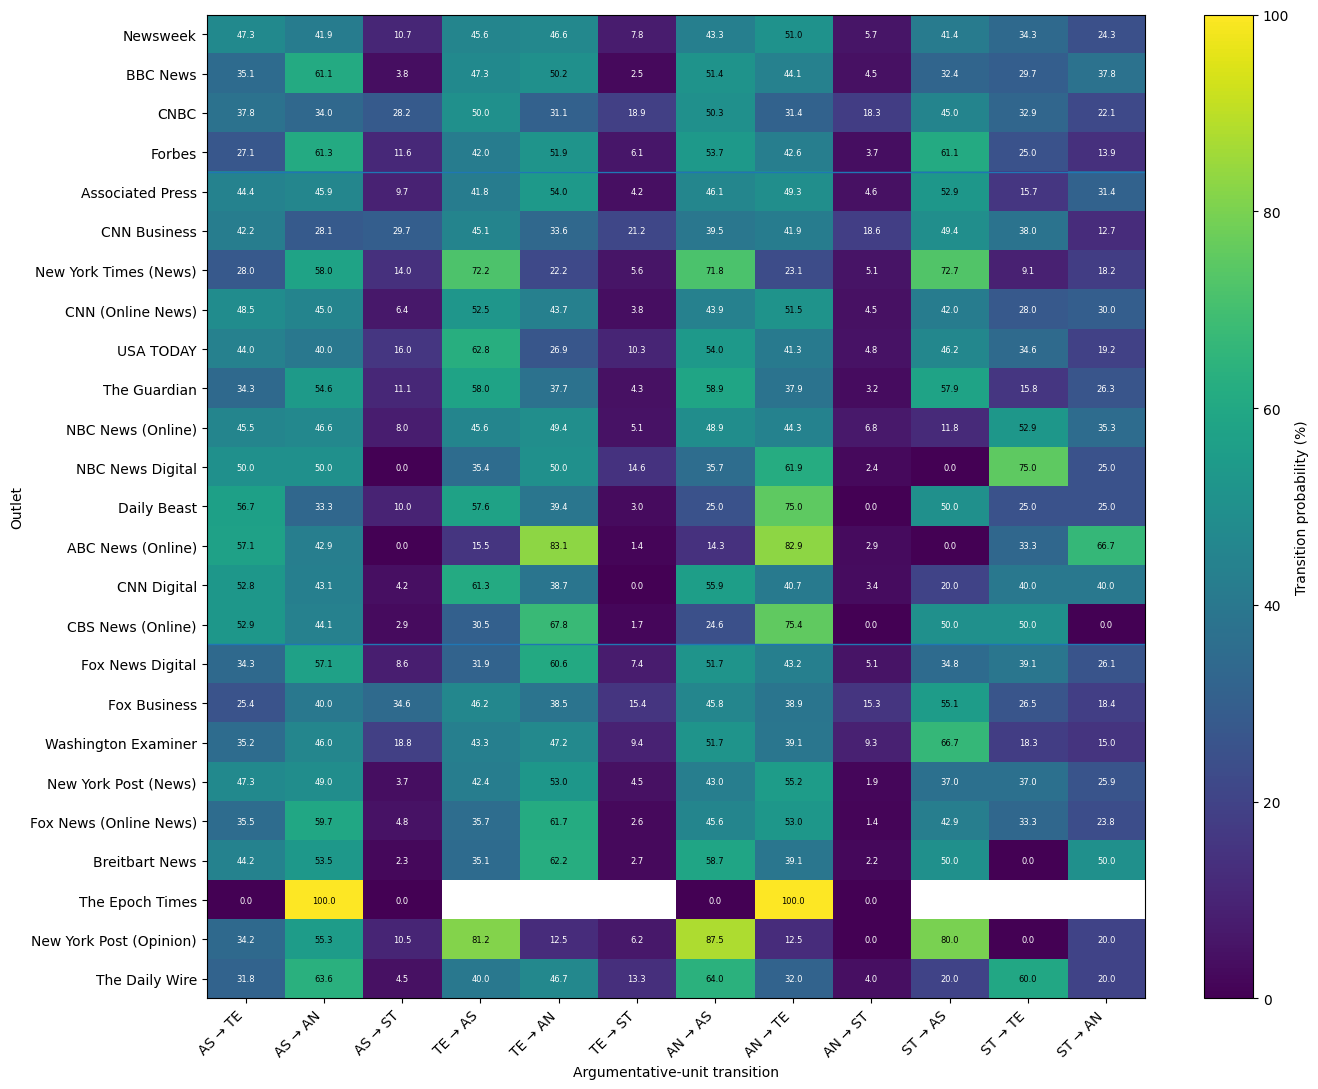

In [27]:
fig, ax = plt.subplots(figsize=(14, 11))

image = ax.imshow(
    outlet_transition_summary.values,
    aspect="auto",
    cmap="viridis",
    vmin=0,
    vmax=100,
)

ax.set_xticks(range(len(outlet_transition_summary.columns)))
ax.set_xticklabels(
    outlet_transition_summary.columns,
    rotation=45,
    ha="right",
)

ax.set_yticks(range(len(outlet_transition_summary.index)))
ax.set_yticklabels(outlet_transition_summary.index)

ax.set_xlabel("Argumentative-unit transition")
ax.set_ylabel("Outlet")

for i in range(len(outlet_transition_summary.index)):
    for j in range(len(outlet_transition_summary.columns)):
        value = outlet_transition_summary.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                color="black" if value > 50 else "white",
                fontsize=6,
            )

ax.axhline(3.5, linewidth=1)
ax.axhline(15.5, linewidth=1)

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Transition probability (%)")

plt.tight_layout()

plt.savefig(
    "../figures/allsides_same_events_outlet_transition_heatmap.pdf",
    bbox_inches="tight",
)

plt.show()

Transition patterns vary across individual news outlets. Although movement among assumption, testimony, and anecdote remains dominant for most sources, the relative probabilities of particular transitions differ considerably between outlets, including among outlets assigned to the same political orientation. Transitions involving statistics show especially large variation, although some extreme percentages are based on relatively few occurrences and should therefore be interpreted carefully. Overall, the outlet comparison suggests that source variation is an important component of argumentative-unit sequencing and that the comparatively modest differences observed between pooled political orientations do not capture the full heterogeneity of sequencing patterns across news organizations.

## 8. Matched-Event Statistical Comparison of Transition Patterns

In [28]:
transition_pairs = [
    f"{first} → {second}"
    for first in label_order
    for second in label_order
    if first != second
]

article_transition_counts = (
    transitions_df
    .assign(
        transition=lambda x:
        x["from_label"] + " → " + x["to_label"]
    )
    .groupby(["event_id", "orientation", "transition"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=transition_pairs, fill_value=0)
    .reindex(
        article_sequences
        .set_index(["event_id", "orientation"])
        .index,
        fill_value=0,
    )
)

article_transition_counts["total_transitions"] = (
    article_transition_counts[transition_pairs].sum(axis=1)
)

zero_transition_articles = (
    article_transition_counts["total_transitions"] == 0
)

(
    zero_transition_articles.sum(),
    article_transition_counts.loc[
        zero_transition_articles
    ].index.get_level_values("event_id").nunique(),
)

(np.int64(9), 9)

In [29]:
valid_event_ids = (
    article_transition_counts
    .assign(
        has_transitions=lambda x:
        x["total_transitions"] > 0
    )
    .groupby(level="event_id")["has_transitions"]
    .all()
    .loc[lambda x: x]
    .index
)

len(valid_event_ids)

211

In [30]:
valid_transition_counts = (
    article_transition_counts.loc[
        article_transition_counts.index.get_level_values("event_id").isin(valid_event_ids)
    ]
)

article_transition_shares = (
    valid_transition_counts[transition_pairs]
    .div(
        valid_transition_counts["total_transitions"],
        axis=0,
    )
)

article_transition_shares.shape

(633, 12)

In [31]:
from scipy.stats import friedmanchisquare
from statsmodels.stats.multitest import multipletests

results = []

for transition in transition_pairs:
    matched = (
        article_transition_shares[transition]
        .unstack("orientation")
        [["Center", "Left", "Right"]]
    )

    chi_squared, p_value = friedmanchisquare(
        matched["Center"],
        matched["Left"],
        matched["Right"],
    )

    kendalls_w = chi_squared / (
        len(matched) * (3 - 1)
    )

    results.append({
        "transition": transition,
        "chi_squared": chi_squared,
        "p_value": p_value,
        "kendalls_w": kendalls_w,
    })

transition_test_results = pd.DataFrame(results)

transition_test_results["p_holm"] = multipletests(
    transition_test_results["p_value"],
    method="holm",
)[1]

transition_test_results.round(4)

,transition,chi_squared,p_value,kendalls_w,p_holm
0,AS → TE,6.3824,0.0411,0.0151,0.4935
1,AS → AN,0.8356,0.6585,0.0020,1.0000
2,AS → ST,0.7763,0.6783,0.0018,1.0000
3,TE → AS,4.1642,0.1247,0.0099,1.0000
4,TE → AN,2.2670,0.3219,0.0054,1.0000
5,TE → ST,0.3951,0.8208,0.0009,1.0000
6,AN → AS,0.4914,0.7822,0.0012,1.0000
7,AN → TE,1.8588,0.3948,0.0044,1.0000
8,AN → ST,2.1513,0.3411,0.0051,1.0000
9,ST → AS,0.1689,0.9190,0.0004,1.0000


The matched-event statistical comparison provided no evidence of systematic differences in argumentative-unit transition patterns across political orientations. None of the 12 directed transitions remained statistically significant after Holm correction. Although the assumption-to-testimony transition reached the conventional significance threshold before correction, this difference did not remain significant after accounting for multiple comparisons. Kendall's W values were very small across all transitions, indicating only weak systematic differences associated with political orientation when the news event was held constant. Consequently, no post-hoc pairwise comparisons were conducted.

In [32]:
transition_test_results.to_csv(
    "../results/allsides_same_events_sequence_statistical_tests.csv",
    index=False,
)